# 02 — Correlation Analysis
**Project:** AI-based 5G Alarm Analysis — Djezzy  
**Goal:** Explore multiple means of correlation between alarms  
**Methods:** Co-occurrence · Temporal Cross-Correlation · Precursor Detection · Association Rules · Cramér's V · Network Graph

---
## 0. Imports & Configuration

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings('ignore')

from src.correlation import (
    build_cooccurrence_matrix,
    compute_jaccard_similarity,
    compute_cooccurrence_counts,
    build_alarm_timeseries,
    compute_temporal_crosscorrelation,
    find_precursors,
    build_transactions,
    compute_cramers_v,
    compute_cramers_v_matrix,
    build_alarm_graph,
    compute_graph_metrics,
)

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

PARQUET_PATH = '../data/processed/alarms_processed.parquet'
CSV_PATH     = '../data/raw/alarms.csv'
FEATURES_DIR = '../data/features/'
FIGURES_DIR  = '../reports/figures/'
os.makedirs(FEATURES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Ready.')

Ready.


### Load preprocessed data

In [3]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Shape: {df.shape}')

# ── Ensure key columns exist ──────────────────────────────────
if 'occurrencetime_reg' not in df.columns:
    for col in ['Occurrencetime', 'Clearancetime', 'occurrencetime_reg', 'Remote Last Update']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

# ── Rebuild HS labels if missing ──────────────────────────────
mapping_rules = {
    'OML Fault'                  : 'LOSS-OF-ALL CHANNEL',
    'CSL Fault'                  : 'LOSS-OF-ALL CHANNEL',
    'NodeB Unavailable'          : 'LOSS-OF-ALL CHANNEL',
    'NE Is Disconnected'         : 'Pas De Supervision',
    'GSM Cell out of Service'    : '2G cell down',
    'UMTS Cell Unavailable'      : '3G cell down',
    'UMTS Cell Setup Failed'     : '3G cell down',
    'Cell Unavailable'           : '4G cell down',
    'S1ap Link Down'             : 'LOSS-OF-ALL CHANNEL',
    'GSM Local Cell Unusable'    : '2G cell down',
    'NR DU Cell TRP Unavailable' : '5G cell down',
    'NR Cell Unavailable'        : '5G cell down',
    'gNodeB Out of Service'      : 'LOSS-OF-ALL CHANNEL',
}
HS_ALARM_NAMES = set(mapping_rules.keys())

if 'is_HS' not in df.columns:
    df['is_HS']       = df['Alarmname'].isin(HS_ALARM_NAMES)
    df['hs_category'] = df['Alarmname'].map(mapping_rules).fillna('Non-HS')

# ── Quick summary ─────────────────────────────────────────────
print(f'HS alarms  : {df["is_HS"].sum():,} ({df["is_HS"].mean()*100:.2f}%)')
print(f'Non-HS     : {(~df["is_HS"]).sum():,}')
print(f'Alarm types: {df["Alarmname"].nunique()}')
print(f'Sites      : {df["Alarmsource"].nunique()}')
df.head(3)

Shape: (4655881, 31)
HS alarms  : 209,225 (4.49%)
Non-HS     : 4,446,656
Alarm types: 891
Sites      : 6218


,Alarmname,occurrencetime_reg,Businessaffected,codesite,Neobjectidentity,Alarmsource,clear,Clearancetime,Locationinformation,Objectidentityname,Occurrencetime,R Server Id,Severity,Netype,Productname,Status,Type,Clearing Status,Remote Last Update,Logserialnumber,duration_min,is_cleared,hour,day_of_week,date,month,year,is_night,is_weekend,is_HS,hs_category
0,Adjacent Node IP Address Ping Failure,2025-02-22 22:31:46,nan,None,NE=9077,ROR03,Cleared,NaT,"Subrack No.=0, Slot No.=23, Adjacent Node IP Address=10....",ROR03,2025-02-22 22:31:46+01:00,1,Major,BSC6910 GU,Mobile,Unacknowledged and uncleared Alarm,Trunk system,Cleared,2025-02-22 22:35:00,583576234,NaN,False,22.0,Saturday,2025-02-22,2.0,2025.0,False,True,False,Non-HS
1,Parallel Alarm Exceeds the Limit,2025-02-19 07:11:24,yes,None,OS=1,OSS,Cleared,NaT,"RuleID=1980, Source Alarm Information=",OSS,2025-02-19 07:11:24+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,2025-02-19 07:15:00,583246673,NaN,False,7.0,Wednesday,2025-02-19,2.0,2025.0,False,False,False,Non-HS
2,Parallel Alarm Exceeds the Limit,2025-02-19 07:11:26,yes,None,OS=1,OSS,Cleared,NaT,"RuleID=1980, Source Alarm Information=",OSS,2025-02-19 07:11:26+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,2025-02-19 07:15:00,583246678,NaN,False,7.0,Wednesday,2025-02-19,2.0,2025.0,False,False,False,Non-HS


---
## 1. Co-occurrence Analysis (Site × Time Window)
> Which alarms tend to fire **together** on the same site within a 30-minute window?

In [4]:
# ── Build binary co-occurrence matrix ─────────────────────────
TOP_N = 40   # number of most-frequent alarms to keep
WINDOW = 30  # minutes

cooc_matrix = build_cooccurrence_matrix(
    df, window_minutes=WINDOW, top_n_alarms=TOP_N
)
print(f'Co-occurrence matrix  : {cooc_matrix.shape[0]:,} rows  ×  {cooc_matrix.shape[1]} alarm types')
cooc_matrix.head()

Co-occurrence matrix  : 2,156,410 rows  ×  40 alarm types


Alarmname                                         3G CS Call Drop Rate  \
time_bin            Alarmsource                                          
2017-07-14 19:00:00 MBTS_A16X727                                   0.0   
2017-10-24 15:00:00 MBTS_A35X136                                   0.0   
2017-10-26 16:00:00 MBTS_A16X391_Aerroport_2_Acc                   0.0   
2017-11-09 17:00:00 MBTS_A06X172                                   0.0   
                    MBTS_A15X143_El_Khlendja                       0.0   

Alarmname                                         3G PS Call Setup Success Rate  \
time_bin            Alarmsource                                                   
2017-07-14 19:00:00 MBTS_A16X727                                            0.0   
2017-10-24 15:00:00 MBTS_A35X136                                            0.0   
2017-10-26 16:00:00 MBTS_A16X391_Aerroport_2_Acc                            0.0   
2017-11-09 17:00:00 MBTS_A06X172                                            0.0   
                    MBTS_A15X143_El_Khlendja                                0.0   

Alarmname                                         ALD Maintenance Link Failure  \
time_bin            Alarmsource                                                  
2017-07-14 19:00:00 MBTS_A16X727                                           1.0   
2017-10-24 15:00:00 MBTS_A35X136                                           0.0   
2017-10-26 16:00:00 MBTS_A16X391_Aerroport_2_Acc                           1.0   
2017-11-09 17:00:00 MBTS_A06X172                                           0.0   
                    MBTS_A15X143_El_Khlendja                               0.0   

Alarmname                                         Adjacent Node IP Address Ping Failure  \
time_bin            Alarmsource                                                           
2017-07-14 19:00:00 MBTS_A16X727                                                    0.0   
2017-10-24 15:00:00 MBTS_A35X136                                                    0.0   
2017-10-26 16:00:00 MBTS_A16X391_Aerroport_2_Acc                                    0.0   
2017-11-09 17:00:00 MBTS_A06X172                                                    0.0   
                    MBTS_A15X143_El_Khlendja                                        0.0   

Alarmname                                         Adjacent Node IP Path Ping Failure  \
time_bin            Alarmsource                                                        
2017-07-14 19:00:00 MBTS_A16X727                                                 0.0   
2017-10-24 15:00:00 MBTS_A35X136                                                 0.0   
2017-10-26 16:00:00 MBTS_A16X391_Aerroport_2_Acc                                 0.0   
2017-11-09 17:00:00 MBTS_A06X172                                                 0.0   
                    MBTS_A15X143_El_Khlendja                                     0.0   

Alarmname                                         Air Cond. Alarm  \
time_bin            Alarmsource                                     
2017-07-14 19:00:00 MBTS_A16X727                              0.0   
2017-10-24 15:00:00 MBTS_A35X136                              0.0   
2017-10-26 16:00:00 MBTS_A16X391_Aerroport_2_Acc              0.0   
2017-11-09 17:00:00 MBTS_A06X172                              0.0   
                    MBTS_A15X143_El_Khlendja                  0.0   

Alarmname                                         Cell Blocked  Cell Outage  \
time_bin            Alarmsource                                               
2017-07-14 19:00:00 MBTS_A16X727                           0.0          0.0   
2017-10-24 15:00:00 MBTS_A35X136                           0.0          0.0   
2017-10-26 16:00:00 MBTS_A16X391_Aerroport_2_Acc           0.0          0.0   
2017-11-09 17:00:00 MBTS_A06X172                           0.0          0.0   
                    MBTS_A15X143_El_Khlendja               0.0          0.0   

Alarmname                      

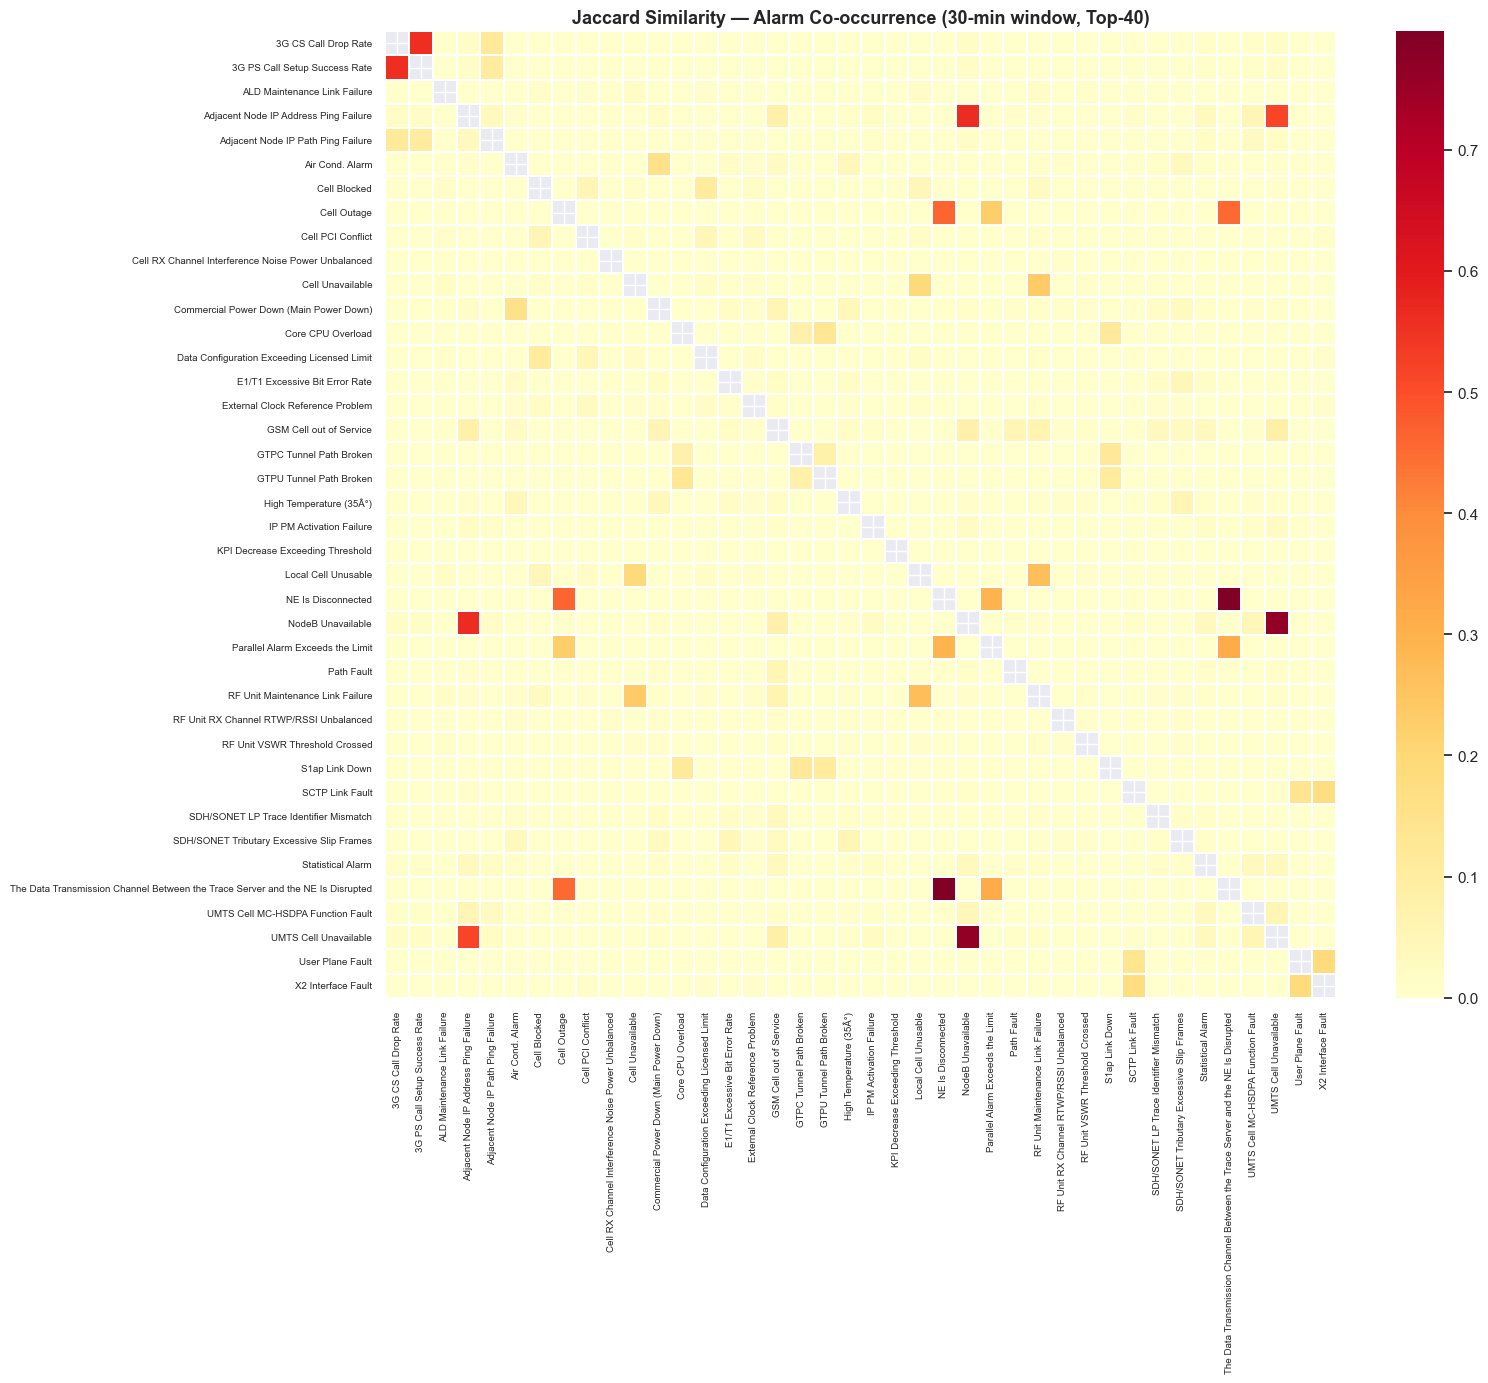

In [5]:
# ── Jaccard Similarity ────────────────────────────────────────
jaccard = compute_jaccard_similarity(cooc_matrix)

# Mask diagonal for better visualisation
mask = np.eye(len(jaccard), dtype=bool)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(jaccard.where(~mask), cmap='YlOrRd', annot=False,
            linewidths=.3, ax=ax, vmin=0)
ax.set_title(f'Jaccard Similarity — Alarm Co-occurrence ({WINDOW}-min window, Top-{TOP_N})',
             fontweight='bold', fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'corr_jaccard_heatmap.png', dpi=150)
plt.show()

In [6]:
# ── Top co-occurring pairs ────────────────────────────────────
cooc_counts = compute_cooccurrence_counts(cooc_matrix)

# flatten upper triangle
pairs = []
cols = cooc_counts.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append({
            'alarm_A': cols[i],
            'alarm_B': cols[j],
            'cooccurrence_count': int(cooc_counts.iloc[i, j]),
            'jaccard': jaccard.iloc[i, j],
        })
pairs_df = pd.DataFrame(pairs).sort_values('jaccard', ascending=False)
print('=== Top-20 co-occurring alarm pairs (Jaccard) ===')
pairs_df.head(20)

=== Top-20 co-occurring alarm pairs (Jaccard) ===


,alarm_A,alarm_B,cooccurrence_count,jaccard
655,NE Is Disconnected,The Data Transmission Channel Between the Trace Server a...,1,0.797755
672,NodeB Unavailable,UMTS Cell Unavailable,1,0.763728
134,Adjacent Node IP Address Ping Failure,NodeB Unavailable,1,0.561548
0,3G CS Call Drop Rate,3G PS Call Setup Success Rate,1,0.559092
147,Adjacent Node IP Address Ping Failure,UMTS Cell Unavailable,1,0.516235
267,Cell Outage,NE Is Disconnected,1,0.462981
279,Cell Outage,The Data Transmission Channel Between the Trace Server a...,1,0.453367
684,Parallel Alarm Exceeds the Limit,The Data Transmission Channel Between the Trace Server a...,1,0.317999
645,NE Is Disconnected,Parallel Alarm Exceeds the Limit,1,0.289980
631,Local Cell Unusable,RF Unit Maintenance Link Failure,1,0.268909


In [7]:
# Save co-occurrence features
jaccard.to_csv(FEATURES_DIR + 'jaccard_similarity.csv')
pairs_df.to_csv(FEATURES_DIR + 'cooccurrence_pairs.csv', index=False)
print('Saved → jaccard_similarity.csv, cooccurrence_pairs.csv')

Saved → jaccard_similarity.csv, cooccurrence_pairs.csv


---
## 2. Temporal Cross-Correlation (Time Series)
> Treat hourly alarm counts as time series and measure **lagged** Pearson correlations.

In [8]:
# ── Build hourly time series ──────────────────────────────────
TS_TOP_N = 25
MAX_LAG  = 12  # hours

ts = build_alarm_timeseries(df, freq='1h', top_n=TS_TOP_N)
print(f'Time-series shape: {ts.shape}')
ts.head()

Time-series shape: (7480, 25)


Alarmname,Adjacent Node IP Address Ping Failure,Cell Blocked,Cell Outage,Cell RX Channel Interference Noise Power Unbalanced,Cell Unavailable,Commercial Power Down (Main Power Down),Core CPU Overload,E1/T1 Excessive Bit Error Rate,External Clock Reference Problem,GSM Cell out of Service,GTPC Tunnel Path Broken,High Temperature (35Â°),IP PM Activation Failure,Local Cell Unusable,Parallel Alarm Exceeds the Limit,RF Unit RX Channel RTWP/RSSI Unbalanced,RF Unit VSWR Threshold Crossed,S1ap Link Down,SCTP Link Fault,SDH/SONET Tributary Excessive Slip Frames,Statistical Alarm,UMTS Cell MC-HSDPA Function Fault,UMTS Cell Unavailable,User Plane Fault,X2 Interface Fault
time_bin,,,,,,,,,,,,,,,,,,,,,,,,,
2017-10-24 15:00:00,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0
2017-11-09 17:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,26,0,1,2,0,0,0,0,0,0,0,0
2017-11-09 18:00:00,0,0,0,0,3,0,0,0,1,0,0,0,0,2,0,4,1,0,10,0,0,0,0,0,0
2017-11-09 19:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0
2017-11-09 20:00:00,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,1,0,27,0,0,0,0,0,0


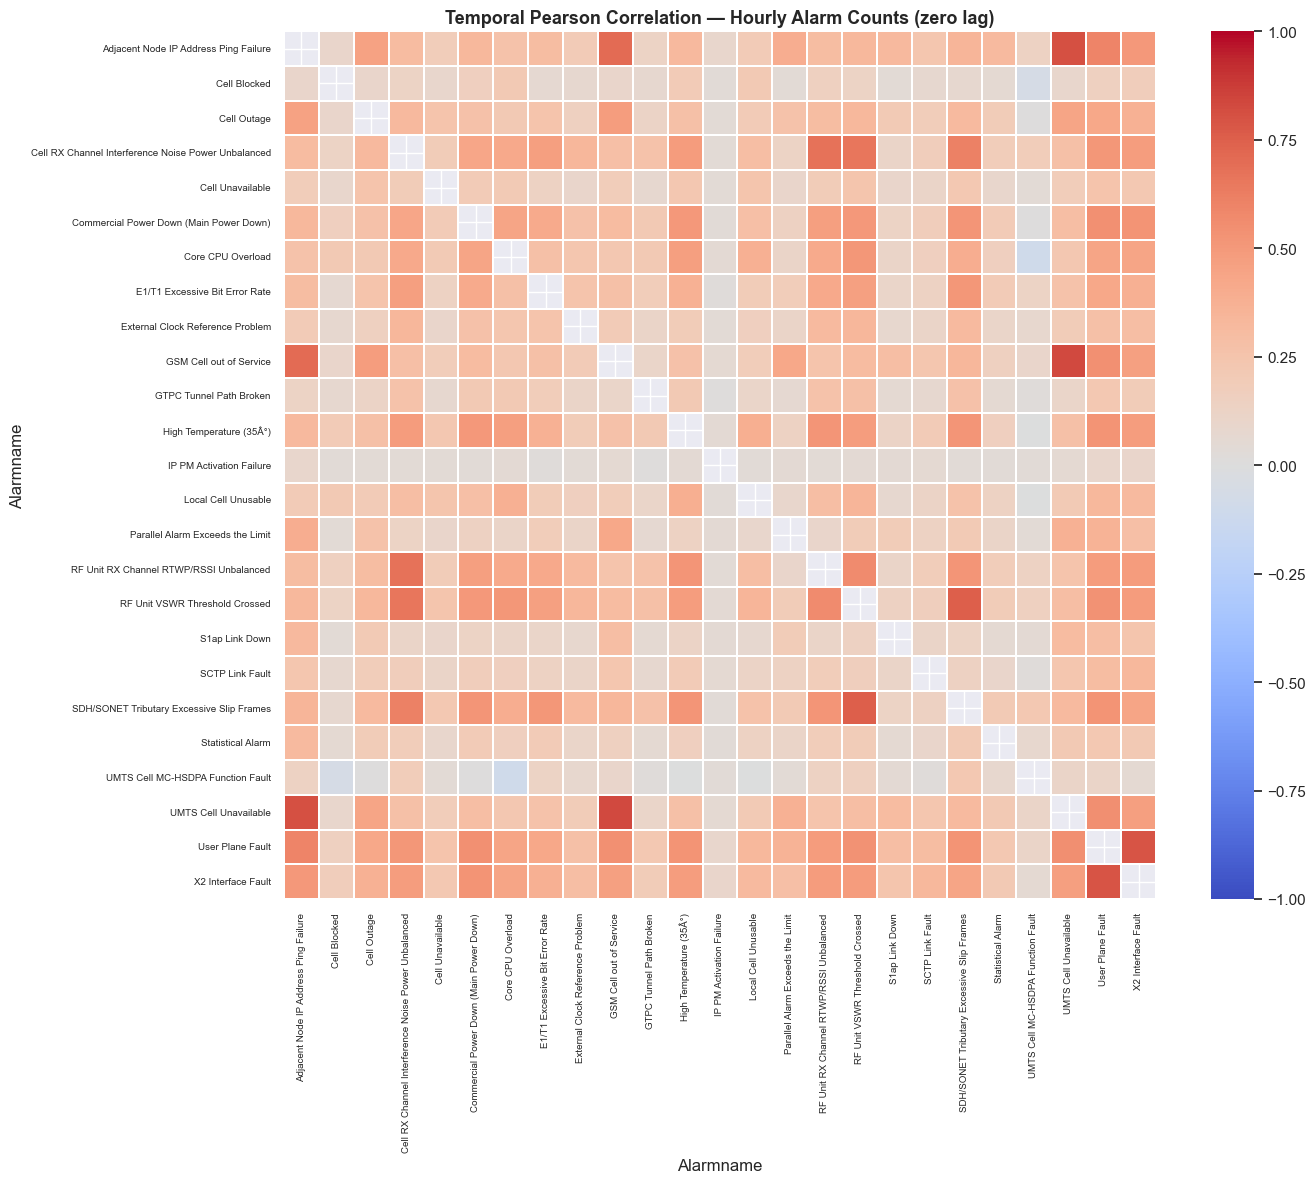

In [9]:
# ── Zero-lag correlation matrix ───────────────────────────────
corr_matrix, lag_df = compute_temporal_crosscorrelation(ts, max_lag=MAX_LAG)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.eye(len(corr_matrix), dtype=bool)
sns.heatmap(corr_matrix.where(~mask), cmap='coolwarm', center=0,
            annot=False, linewidths=.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Temporal Pearson Correlation — Hourly Alarm Counts (zero lag)',
             fontweight='bold', fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'corr_temporal_heatmap.png', dpi=150)
plt.show()

=== Top-15 temporally correlated pairs (best lag) ===


,alarm_1,alarm_2,lag,correlation
0,GSM Cell out of Service,UMTS Cell Unavailable,0,0.835005
1,Adjacent Node IP Address Ping Failure,UMTS Cell Unavailable,0,0.808960
2,User Plane Fault,X2 Interface Fault,0,0.791526
3,RF Unit VSWR Threshold Crossed,SDH/SONET Tributary Excessive Slip Frames,0,0.751934
4,Adjacent Node IP Address Ping Failure,GSM Cell out of Service,0,0.703313
5,Cell RX Channel Interference Noise Power Unbalanced,RF Unit RX Channel RTWP/RSSI Unbalanced,0,0.675672
6,Cell RX Channel Interference Noise Power Unbalanced,RF Unit VSWR Threshold Crossed,0,0.656580
7,Cell Unavailable,SCTP Link Fault,-9,0.647353
8,Cell RX Channel Interference Noise Power Unbalanced,SDH/SONET Tributary Excessive Slip Frames,0,0.614176
9,Adjacent Node IP Address Ping Failure,User Plane Fault,0,0.599093


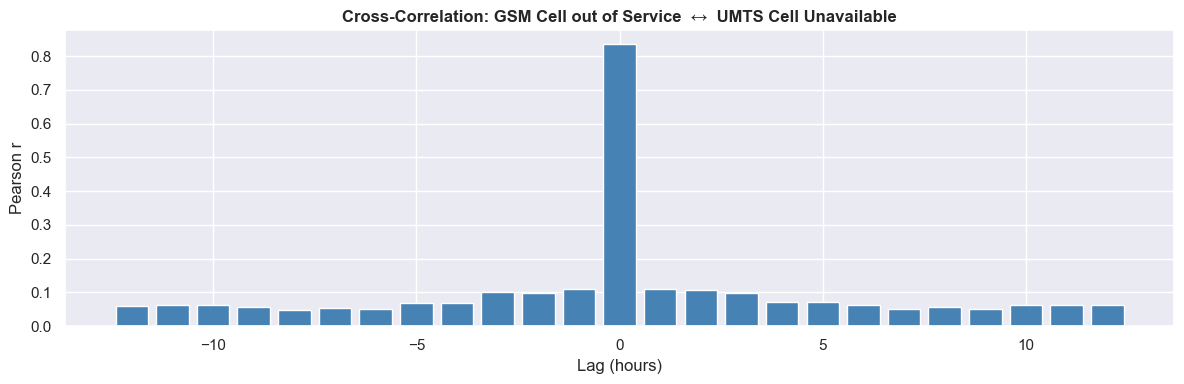

In [10]:
# ── Top correlated pairs at any lag ───────────────────────────
if len(lag_df) > 0:
    # best absolute correlation per pair
    lag_df['abs_corr'] = lag_df['correlation'].abs()
    best = (lag_df.sort_values('abs_corr', ascending=False)
                  .drop_duplicates(subset=['alarm_1','alarm_2'])
                  .head(15))
    print('=== Top-15 temporally correlated pairs (best lag) ===')
    display(best[['alarm_1','alarm_2','lag','correlation']].reset_index(drop=True))

    # Plot cross-correlation function for top pair
    top_a1, top_a2 = best.iloc[0]['alarm_1'], best.iloc[0]['alarm_2']
    sub = lag_df[(lag_df['alarm_1']==top_a1)&(lag_df['alarm_2']==top_a2)]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(sub['lag'], sub['correlation'], color='steelblue')
    ax.set_xlabel('Lag (hours)')
    ax.set_ylabel('Pearson r')
    ax.set_title(f'Cross-Correlation: {top_a1}  ↔  {top_a2}', fontweight='bold')
    ax.axhline(0, color='grey', ls='--', lw=.8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'corr_lag_top_pair.png', dpi=150)
    plt.show()

In [11]:
# Save temporal correlation features
corr_matrix.to_csv(FEATURES_DIR + 'temporal_correlation_matrix.csv')
if len(lag_df) > 0:
    lag_df.to_csv(FEATURES_DIR + 'temporal_lag_correlations.csv', index=False)
print('Saved → temporal_correlation_matrix.csv, temporal_lag_correlations.csv')

Saved → temporal_correlation_matrix.csv, temporal_lag_correlations.csv


---
## 3. Sequential Precursor Detection (Non-HS → HS)
> Which **Non-HS** alarms commonly **precede** each HS category on the same site?

In [12]:
# ── Precursor analysis ────────────────────────────────────────
LOOKBACK = 60  # minutes

precursors_df, n_sampled = find_precursors(
    df, lookback_minutes=LOOKBACK, sample_hs=5000
)

print(f'HS events sampled : {n_sampled:,}')
print(f'Unique precursors : {precursors_df["precursor_alarm"].nunique()}')
precursors_df.head(15)

HS events sampled : 5,000
Unique precursors : 231


,precursor_alarm,hs_category,count,frequency
0,SCTP Link Fault,3G cell down,1411,0.2822
1,Adjacent Node IP Address Ping Failure,3G cell down,1380,0.2760
7,UMTS Cell MC-HSDPA Function Fault,3G cell down,490,0.0980
50,SCTP Link Fault,LOSS-OF-ALL CHANNEL,420,0.0840
49,Adjacent Node IP Address Ping Failure,LOSS-OF-ALL CHANNEL,376,0.0752
9,SCTP Link Fault,2G cell down,356,0.0712
11,ESL Link Fault,2G cell down,347,0.0694
4,The Data Transmission Channel Between the Trace Server a...,Pas De Supervision,325,0.0650
3,Cell Outage,Pas De Supervision,293,0.0586
75,E1/T1 Alarm Indication Signal,2G cell down,282,0.0564


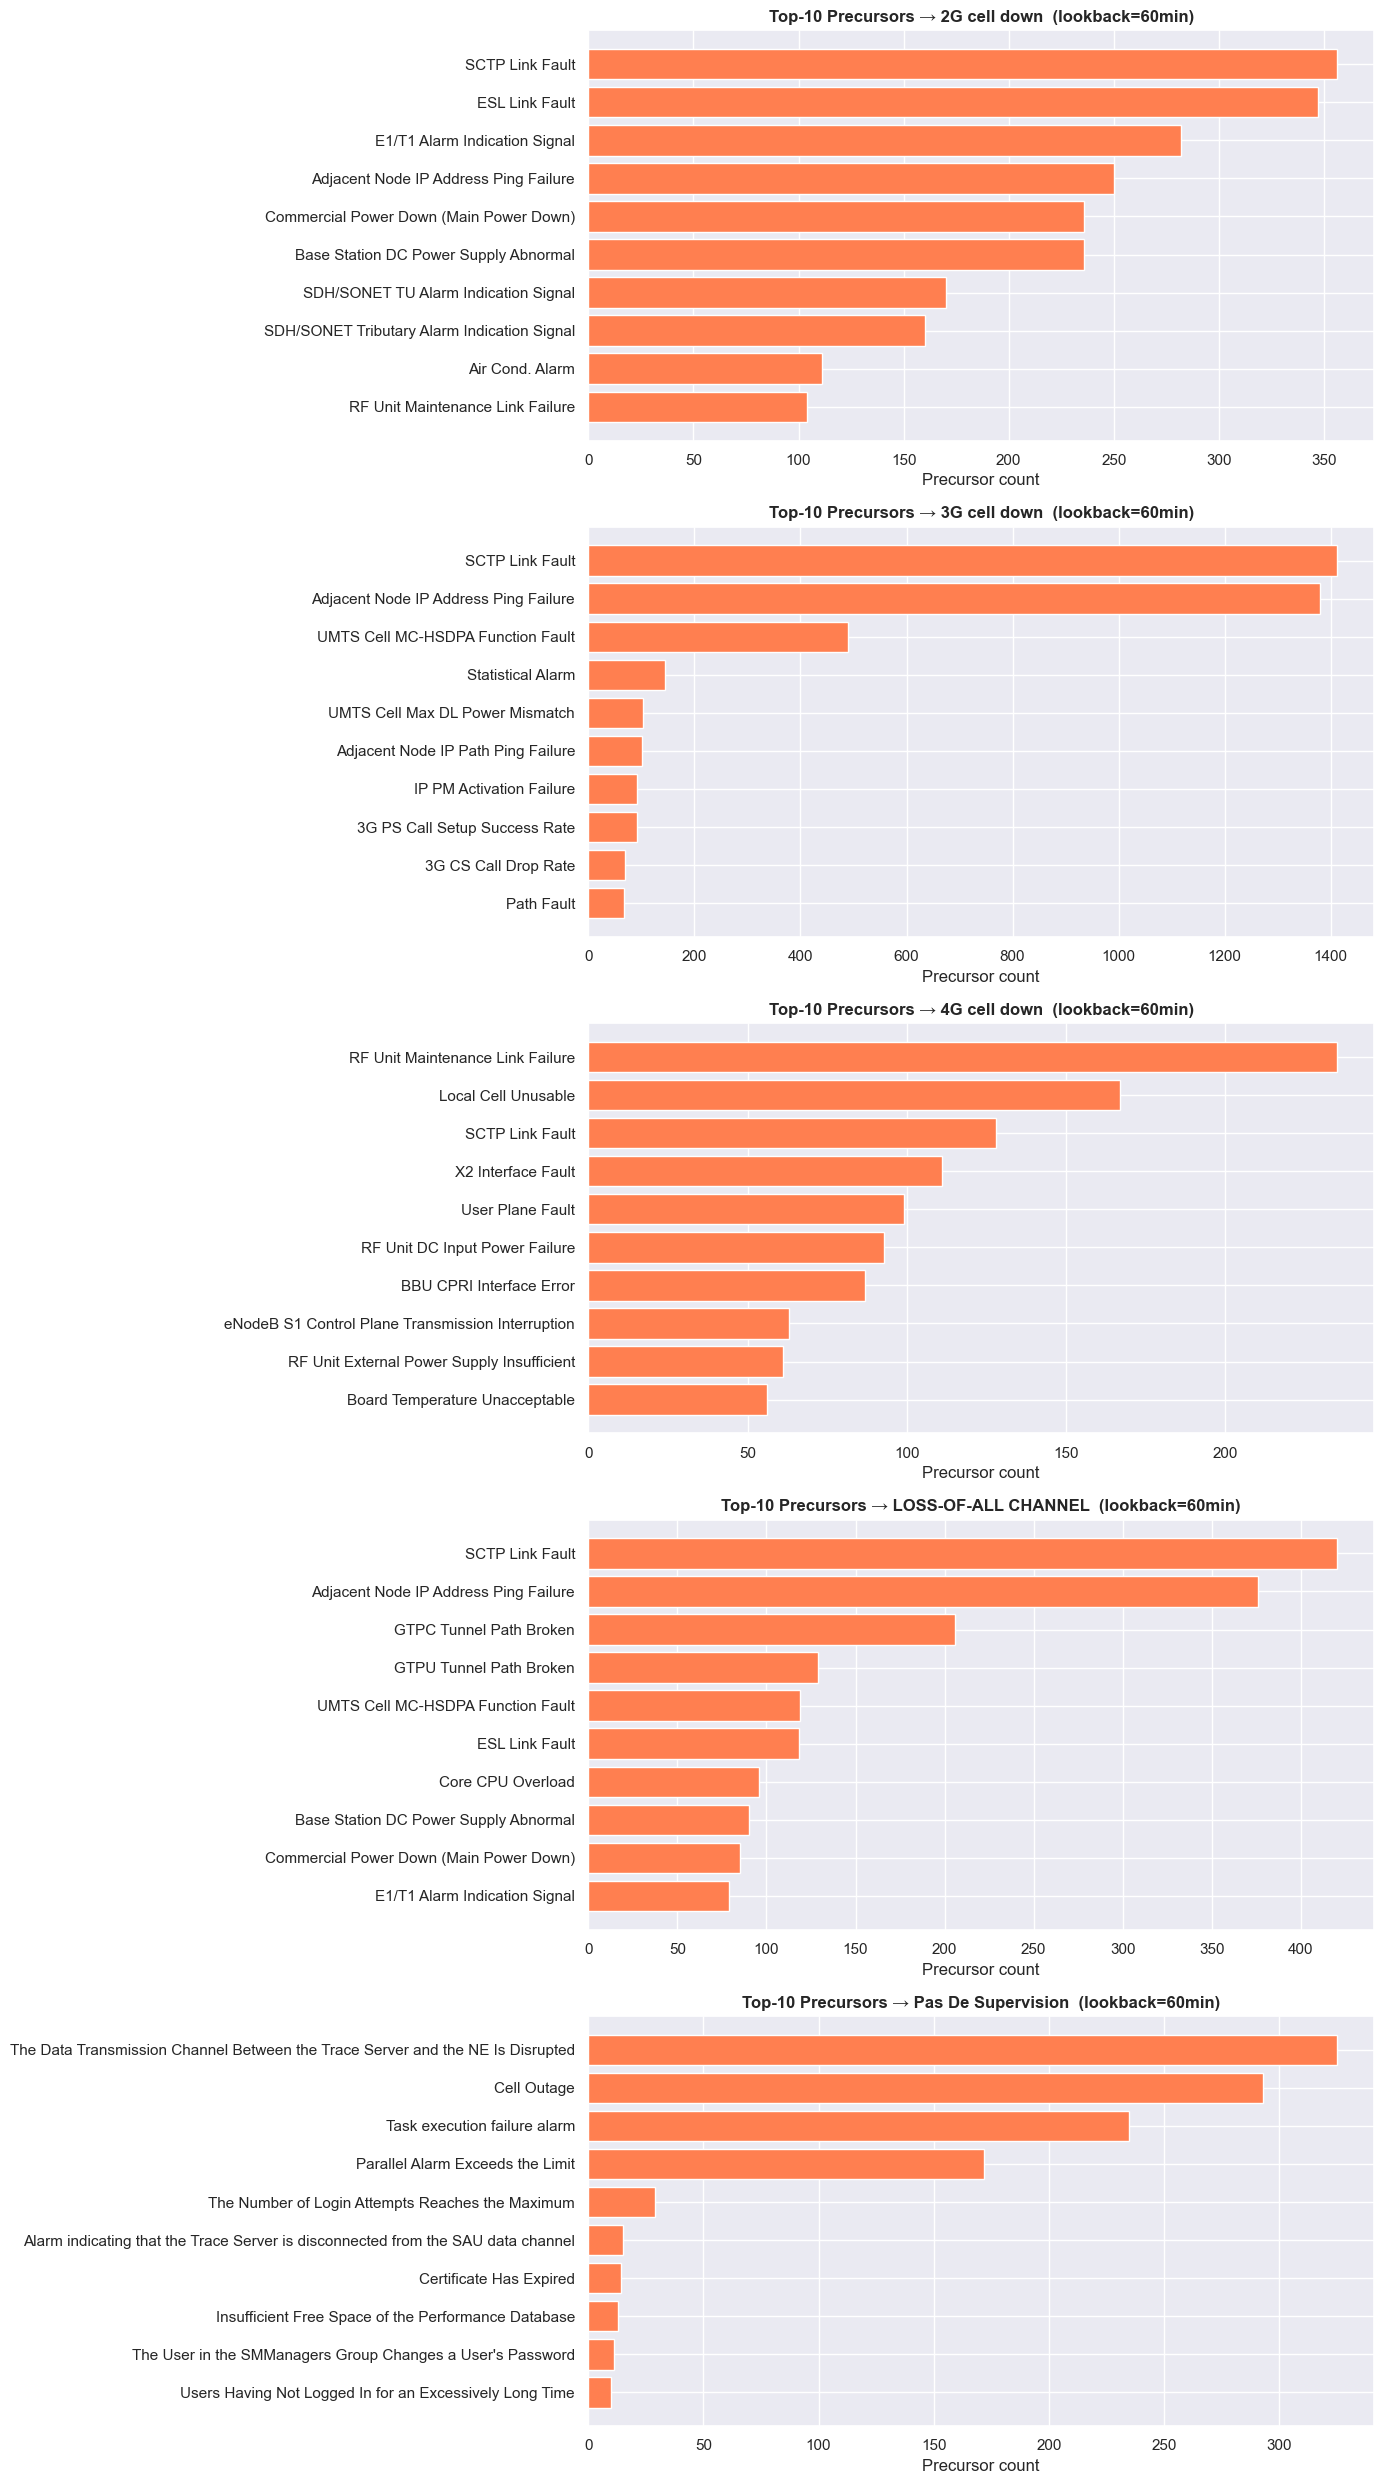

In [13]:
# ── Top precursors per HS category ────────────────────────────
hs_cats = precursors_df['hs_category'].unique()
n_cats = len(hs_cats)

fig, axes = plt.subplots(n_cats, 1, figsize=(14, 5 * n_cats), squeeze=False)

for idx, cat in enumerate(sorted(hs_cats)):
    sub = precursors_df[precursors_df['hs_category'] == cat].head(10)
    ax = axes[idx, 0]
    bars = ax.barh(sub['precursor_alarm'], sub['count'], color='coral')
    ax.set_xlabel('Precursor count')
    ax.set_title(f'Top-10 Precursors → {cat}  (lookback={LOOKBACK}min)',
                 fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'corr_precursors_per_hs.png', dpi=150)
plt.show()

In [14]:
# Save precursor features
precursors_df.to_csv(FEATURES_DIR + 'precursor_rankings.csv', index=False)
print('Saved → precursor_rankings.csv')

Saved → precursor_rankings.csv


---
## 4. Association Rule Mining (FP-Growth)
> Discover **frequent alarm combinations** and extract rules with support / confidence / lift.

In [15]:
# ── Build transactions & apply FP-Growth ──────────────────────
ASSOC_TOP_N = 35
MIN_SUPPORT = 0.01

transactions = build_transactions(
    df, window_minutes=30, top_n_alarms=ASSOC_TOP_N, min_items=2
)
print(f'Transactions: {len(transactions):,}  |  Items: {transactions.shape[1]}')

freq_items = fpgrowth(transactions, min_support=MIN_SUPPORT, use_colnames=True)
print(f'Frequent itemsets found: {len(freq_items)}')
freq_items.sort_values('support', ascending=False).head(15)

Transactions: 545,492  |  Items: 35
Frequent itemsets found: 26


,support,itemsets
0,0.745833,(SCTP Link Fault)
4,0.678487,(X2 Interface Fault)
3,0.598707,(User Plane Fault)
14,0.492236,"(SCTP Link Fault, X2 Interface Fault)"
11,0.413300,"(SCTP Link Fault, User Plane Fault)"
12,0.363925,"(X2 Interface Fault, User Plane Fault)"
13,0.180514,"(SCTP Link Fault, X2 Interface Fault, User Plane Fault)"
7,0.015630,(Adjacent Node IP Address Ping Failure)
8,0.014792,(UMTS Cell Unavailable)
6,0.014603,(NodeB Unavailable)


In [16]:
# ── Extract association rules ─────────────────────────────────
if len(freq_items) > 0:
    rules = association_rules(freq_items, metric='lift', min_threshold=1.0)
    rules = rules.sort_values('lift', ascending=False)
    
    # Convert frozensets to strings for readability
    rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
    
    print(f'Association rules found: {len(rules)}')
    display(rules[['antecedents_str','consequents_str','support','confidence','lift']].head(20))
else:
    rules = pd.DataFrame()
    print('No frequent itemsets found. Try lowering MIN_SUPPORT.')

Association rules found: 50


,antecedents_str,consequents_str,support,confidence,lift
29,"SCTP Link Fault, UMTS Cell Unavailable","Adjacent Node IP Address Ping Failure, NodeB Unavailable",0.012176,0.951440,76.100103
32,"Adjacent Node IP Address Ping Failure, NodeB Unavailable","SCTP Link Fault, UMTS Cell Unavailable",0.012176,0.973900,76.100103
33,"Adjacent Node IP Address Ping Failure, UMTS Cell Unavail...","NodeB Unavailable, SCTP Link Fault",0.012176,0.978347,71.808482
28,"NodeB Unavailable, SCTP Link Fault","Adjacent Node IP Address Ping Failure, UMTS Cell Unavail...",0.012176,0.893703,71.808482
35,NodeB Unavailable,"Adjacent Node IP Address Ping Failure, SCTP Link Fault, ...",0.012176,0.833794,67.996375
26,"Adjacent Node IP Address Ping Failure, SCTP Link Fault, ...",NodeB Unavailable,0.012176,0.992974,67.996375
10,NodeB Unavailable,"SCTP Link Fault, UMTS Cell Unavailable",0.012689,0.868943,67.898791
7,"SCTP Link Fault, UMTS Cell Unavailable",NodeB Unavailable,0.012689,0.991548,67.898791
21,NodeB Unavailable,"Adjacent Node IP Address Ping Failure, UMTS Cell Unavail...",0.012301,0.842330,67.680693
20,"Adjacent Node IP Address Ping Failure, UMTS Cell Unavail...",NodeB Unavailable,0.012301,0.988364,67.680693


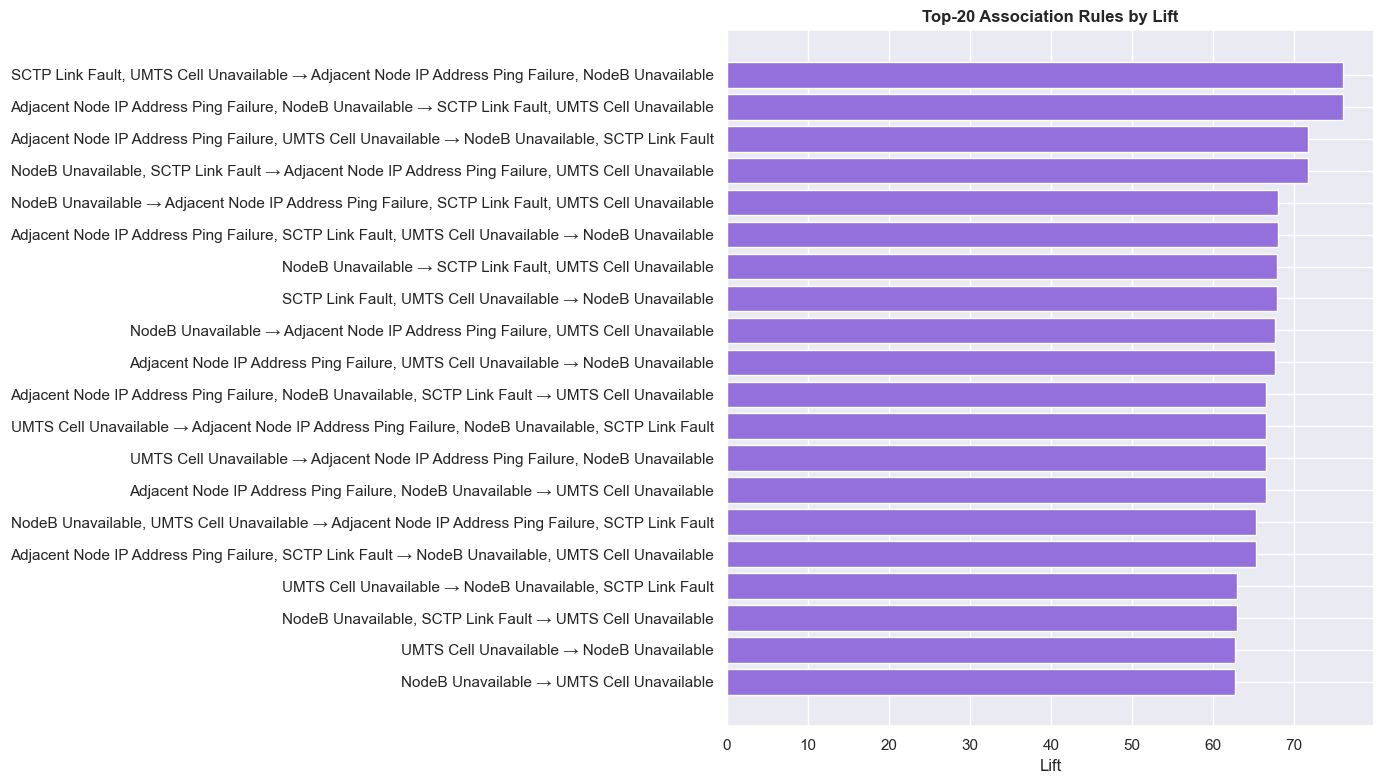

In [17]:
# ── Visualise top rules ───────────────────────────────────────
if len(rules) > 0:
    top_rules = rules.head(20).copy()
    top_rules['rule'] = top_rules['antecedents_str'] + ' → ' + top_rules['consequents_str']

    fig, ax = plt.subplots(figsize=(14, 8))
    bars = ax.barh(top_rules['rule'], top_rules['lift'], color='mediumpurple')
    ax.set_xlabel('Lift')
    ax.set_title('Top-20 Association Rules by Lift', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'corr_association_rules_lift.png', dpi=150)
    plt.show()

    # Scatter: support vs confidence, size = lift
    fig = px.scatter(rules.head(50), x='support', y='confidence',
                     size='lift', color='lift',
                     hover_data=['antecedents_str','consequents_str'],
                     title='Association Rules — Support vs Confidence (size=Lift)',
                     color_continuous_scale='Viridis')
    fig.show()

In [18]:
# Save association rule features
if len(rules) > 0:
    rules[['antecedents_str','consequents_str','support','confidence','lift']].to_csv(
        FEATURES_DIR + 'association_rules.csv', index=False)
    print('Saved → association_rules.csv')

Saved → association_rules.csv


---
## 5. Statistical Correlation — Cramér's V & Chi-Squared
> Measure **statistical association** between categorical alarm attributes.

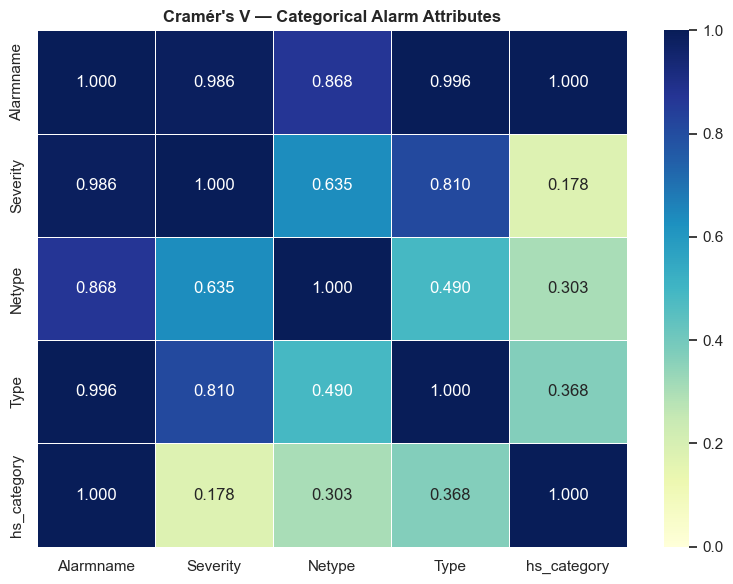

In [19]:
# ── Cramér's V matrix ─────────────────────────────────────────
# Use a sample for speed (1M rows is enough for robust statistics)
sample_size = min(1_000_000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

cat_cols = ['Alarmname', 'Severity', 'Netype', 'Type', 'hs_category']
# ensure all are strings
for c in cat_cols:
    df_sample[c] = df_sample[c].astype(str)

cramers = compute_cramers_v_matrix(df_sample, cat_cols)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cramers, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, linewidths=.5, ax=ax)
ax.set_title("Cramér's V — Categorical Alarm Attributes", fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'corr_cramers_v.png', dpi=150)
plt.show()

In [20]:
# ── Per-pair Chi-squared test (top pairs) ─────────────────────
from scipy.stats import chi2_contingency

chi2_results = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        ct = pd.crosstab(df_sample[cat_cols[i]], df_sample[cat_cols[j]])
        chi2, p, dof, _ = chi2_contingency(ct)
        chi2_results.append({
            'variable_1': cat_cols[i],
            'variable_2': cat_cols[j],
            'chi2': chi2,
            'p_value': p,
            'dof': dof,
            'cramers_v': cramers.loc[cat_cols[i], cat_cols[j]],
            'significant': p < 0.001
        })

chi2_df = pd.DataFrame(chi2_results).sort_values('cramers_v', ascending=False)
print('=== Chi-squared Independence Tests ===')
chi2_df

=== Chi-squared Independence Tests ===


,variable_1,variable_2,chi2,p_value,dof,cramers_v,significant
3,Alarmname,hs_category,6.000000e+06,0.0,4212,1.000000,True
2,Alarmname,Type,1.489382e+07,0.0,10530,0.996454,True
0,Alarmname,Severity,3.890994e+06,0.0,2808,0.986280,True
1,Alarmname,Netype,2.110260e+07,0.0,19656,0.868138,True
5,Severity,Type,2.626730e+06,0.0,60,0.810359,True
4,Severity,Netype,1.613853e+06,0.0,112,0.635187,True
7,Netype,Type,3.602130e+06,0.0,420,0.490043,True
9,Type,hs_category,8.122874e+05,0.0,90,0.367942,True
8,Netype,hs_category,5.519876e+05,0.0,168,0.303312,True
6,Severity,hs_category,1.262168e+05,0.0,24,0.177635,True


In [21]:
# Save statistical correlation features
cramers.to_csv(FEATURES_DIR + 'cramers_v_matrix.csv')
chi2_df.to_csv(FEATURES_DIR + 'chi2_tests.csv', index=False)
print('Saved → cramers_v_matrix.csv, chi2_tests.csv')

Saved → cramers_v_matrix.csv, chi2_tests.csv


---
## 6. Network Graph Analysis
> Build a **graph** where nodes = alarm types and edges = co-occurrence strength.  
> Identify **hub** alarms and natural **communities**.

In [22]:
# ── Build alarm graph from Jaccard similarity ─────────────────
GRAPH_THRESHOLD = 0.02

G = build_alarm_graph(jaccard, threshold=GRAPH_THRESHOLD)
print(f'Graph nodes: {G.number_of_nodes()}  |  edges: {G.number_of_edges()}')

# ── Compute centrality & community metrics ────────────────────
metrics_df = compute_graph_metrics(G)
metrics_df = metrics_df.sort_values('pagerank', ascending=False)
print('\n=== Top-15 alarms by PageRank ===')
metrics_df.head(15)

Graph nodes: 40  |  edges: 62

=== Top-15 alarms by PageRank ===


,degree_centrality,betweenness_centrality,pagerank,community
NodeB Unavailable,0.153846,0.022942,0.065126,0
UMTS Cell Unavailable,0.153846,0.000000,0.064123,0
Adjacent Node IP Address Ping Failure,0.179487,0.004049,0.057881,0
GSM Cell out of Service,0.282051,0.255061,0.043621,0
RF Unit Maintenance Link Failure,0.102564,0.137652,0.043084,1
Local Cell Unusable,0.076923,0.005398,0.037211,1
The Data Transmission Channel Between the Trace Server and the NE Is Disrupted,0.076923,0.000000,0.033626,4
NE Is Disconnected,0.076923,0.000000,0.033244,4
3G CS Call Drop Rate,0.051282,0.000000,0.033224,5
Cell Blocked,0.128205,0.105263,0.032961,1


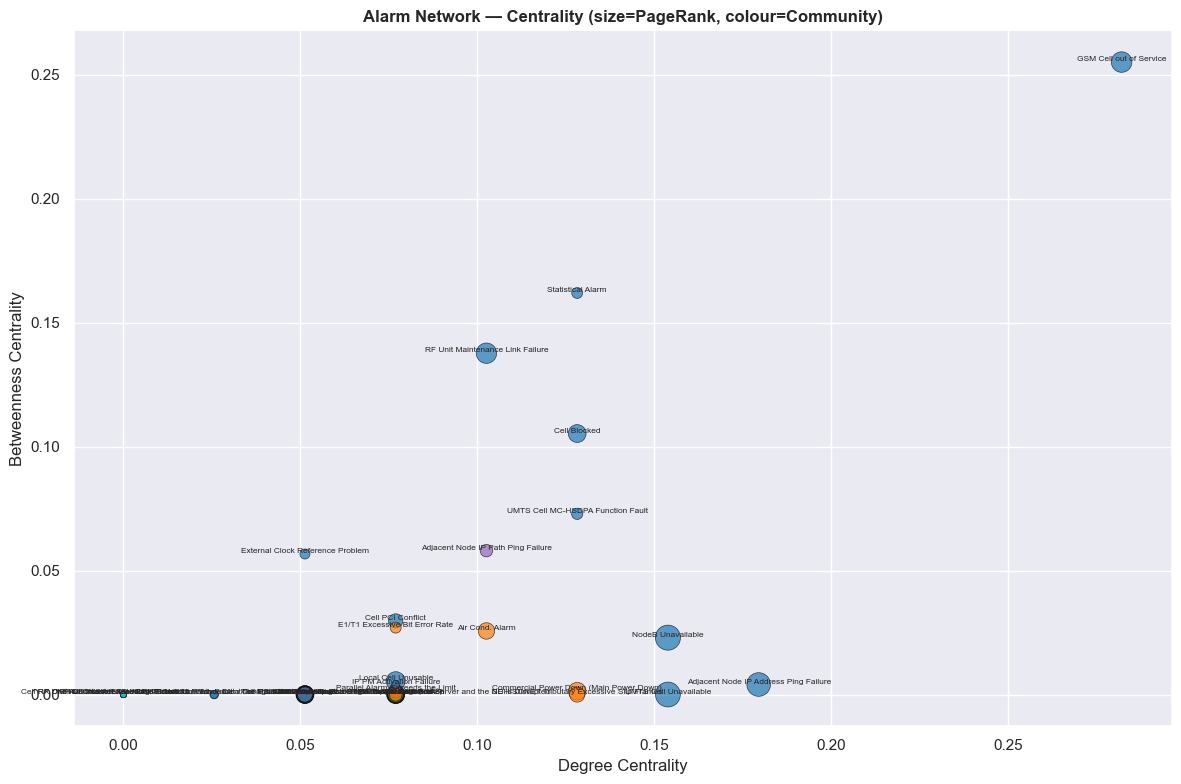

In [23]:
# ── Visualise: degree vs betweenness ──────────────────────────
if len(metrics_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    sc = ax.scatter(
        metrics_df['degree_centrality'],
        metrics_df['betweenness_centrality'],
        c=metrics_df['community'],
        cmap='tab10', s=metrics_df['pagerank']*5000,
        alpha=0.7, edgecolors='black', linewidths=0.5
    )
    for name, row in metrics_df.iterrows():
        ax.annotate(name, (row['degree_centrality'], row['betweenness_centrality']),
                    fontsize=6, ha='center', va='bottom')
    ax.set_xlabel('Degree Centrality')
    ax.set_ylabel('Betweenness Centrality')
    ax.set_title('Alarm Network — Centrality (size=PageRank, colour=Community)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'corr_network_centrality.png', dpi=150)
    plt.show()

In [24]:
# ── Interactive network graph (Plotly) ─────────────────────────
if G.number_of_edges() > 0:
    pos = nx.spring_layout(G, seed=42, weight='weight', k=2)

    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(x=edge_x, y=edge_y,
                            line=dict(width=0.5, color='#888'),
                            hoverinfo='none', mode='lines')

    node_x = [pos[n][0] for n in G.nodes()]
    node_y = [pos[n][1] for n in G.nodes()]
    node_text = list(G.nodes())
    node_size = [max(G.degree(n) * 4, 8) for n in G.nodes()]
    node_color = [metrics_df.loc[n, 'community'] if n in metrics_df.index else 0
                  for n in G.nodes()]

    node_trace = go.Scatter(
        x=node_x, y=node_y, mode='markers+text',
        text=node_text, textposition='top center', textfont=dict(size=7),
        marker=dict(size=node_size, color=node_color,
                    colorscale='Rainbow', line=dict(width=1, color='black')),
        hovertext=node_text
    )

    fig = go.Figure(data=[edge_trace, node_trace],
                    layout=go.Layout(
                        title='Alarm Co-occurrence Network (Jaccard ≥ {})'.format(GRAPH_THRESHOLD),
                        showlegend=False,
                        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                        width=900, height=700
                    ))
    fig.show()

In [25]:
# ── Community summary ─────────────────────────────────────────
if 'community' in metrics_df.columns:
    for cid in sorted(metrics_df['community'].unique()):
        members = metrics_df[metrics_df['community'] == cid].index.tolist()
        print(f'Community {int(cid)} ({len(members)} alarms): {members}')

Community 0 (9 alarms): ['NodeB Unavailable', 'UMTS Cell Unavailable', 'Adjacent Node IP Address Ping Failure', 'GSM Cell out of Service', 'UMTS Cell MC-HSDPA Function Fault', 'Statistical Alarm', 'Path Fault', 'IP PM Activation Failure', 'SDH/SONET LP Trace Identifier Mismatch']
Community 1 (7 alarms): ['RF Unit Maintenance Link Failure', 'Local Cell Unusable', 'Cell Blocked', 'Cell Unavailable', 'Data Configuration Exceeding Licensed Limit', 'Cell PCI Conflict', 'External Clock Reference Problem']
Community 2 (5 alarms): ['Commercial Power Down (Main Power Down)', 'Air Cond. Alarm', 'SDH/SONET Tributary Excessive Slip Frames', 'High Temperature (35Â°)', 'E1/T1 Excessive Bit Error Rate']
Community 3 (4 alarms): ['S1ap Link Down', 'Core CPU Overload', 'GTPU Tunnel Path Broken', 'GTPC Tunnel Path Broken']
Community 4 (4 alarms): ['The Data Transmission Channel Between the Trace Server and the NE Is Disrupted', 'NE Is Disconnected', 'Cell Outage', 'Parallel Alarm Exceeds the Limit']
Comm

In [26]:
# Save graph metrics
metrics_df.to_csv(FEATURES_DIR + 'network_metrics.csv')
print('Saved → network_metrics.csv')

Saved → network_metrics.csv


---
## 7. Summary & Export

### Key Findings
| Method | Key Output |
|---|---|
| Co-occurrence (Jaccard) | Alarm pairs that fire together on same site/window |
| Temporal Cross-Correlation | Time-lagged relationships between alarm time series |
| Precursor Detection | Non-HS alarms that commonly precede HS alarms |
| Association Rules (FP-Growth) | Frequent alarm combinations with support/confidence/lift |
| Cramér's V | Statistical dependencies between categorical attributes |
| Network Graph | Hub alarms, centrality, and natural alarm communities |

### Saved Features
All correlation features are saved to `data/features/` for use in Phase 3 (RCA) and Phase 4 (Prediction).

In [27]:
# ── List all saved feature files ──────────────────────────────
import glob
saved_files = glob.glob(FEATURES_DIR + '*')
for f in sorted(saved_files):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):40s}  {size_kb:8.1f} KB')

# ── List all saved figures ─────────────────────────────────────
print()
saved_figs = glob.glob(FIGURES_DIR + 'corr_*')
for f in sorted(saved_figs):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):40s}  {size_kb:8.1f} KB')

print('\n✅ Phase 2 — Correlation Analysis complete.')

  association_rules.csv                          6.6 KB
  chi2_tests.csv                                 0.7 KB
  cooccurrence_pairs.csv                        52.5 KB
  cramers_v_matrix.csv                           0.5 KB
  jaccard_similarity.csv                        18.3 KB
  network_metrics.csv                            3.2 KB
  precursor_rankings.csv                        25.6 KB
  temporal_correlation_matrix.csv               12.9 KB
  temporal_lag_correlations.csv                706.6 KB

  corr_association_rules_lift.png              222.0 KB
  corr_cramers_v.png                            83.1 KB
  corr_jaccard_heatmap.png                     270.5 KB
  corr_lag_top_pair.png                         34.0 KB
  corr_network_centrality.png                  108.2 KB
  corr_precursors_per_hs.png                   377.7 KB
  corr_temporal_heatmap.png                    194.3 KB

✅ Phase 2 — Correlation Analysis complete.
